# 01 — Visual overview of the DOHMH inspection data

Phase 1, visual companion to `reports/profile_report.txt`. This notebook is **descriptive only** — every chart here profiles *what is in the data*. No analytical angle has been chosen yet.

Each section answers one question we'd ask before deciding what to analyze:
1. **Where** are the inspections (borough composition)?
2. **When** were they done (temporal coverage)?
3. **How complete** are the key columns?
4. **What kind** of inspections appear (`INSPECTION TYPE`)?
5. **Severity signals**: `SCORE`, `CRITICAL FLAG`, `GRADE`, `ACTION`.
6. **Re-inspection cadence**: inspections per restaurant.

Kernel: `Python (intro_ds)`. Reminder: in DOHMH data **higher `SCORE` = worse**, and `GRADE` (A/B/C) is derived from it — we don't recompute either.

In [1]:
# --- Imports & paths -------------------------------------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Repo root = parent of notebooks/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_CSV  = REPO_ROOT / 'data' / 'raw' / 'dohmh_restaurant_inspections.csv'
FIG_DIR  = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot defaults — readable, not flashy.
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 140
plt.rcParams['axes.titleweight'] = 'bold'

PLACEHOLDER_DATE = '01/01/1900'  # DOHMH 'never inspected' sentinel
print('Raw CSV:', RAW_CSV)
print('Figures dir:', FIG_DIR)

Raw CSV: E:\Projects\Inspection\data\raw\dohmh_restaurant_inspections.csv
Figures dir: E:\Projects\Inspection\reports\figures


In [2]:
# --- Load -----------------------------------------------------------------
# Load everything as strings first so blanks/placeholders are visible exactly.
raw = pd.read_csv(RAW_CSV, dtype=str, keep_default_na=False)
raw = raw.apply(lambda c: c.str.strip())

# Typed copies we'll need for plotting. Original `raw` stays untouched.
raw['inspection_dt'] = pd.to_datetime(
    raw['INSPECTION DATE'], format='%m/%d/%Y', errors='coerce'
)
raw['score_num'] = pd.to_numeric(raw['SCORE'], errors='coerce')

# Drop the 01/01/1900 placeholder rows (registered-but-never-inspected).
real = raw[raw['INSPECTION DATE'] != PLACEHOLDER_DATE].copy()

# Collapse violation-grain to INSPECTION grain — one row per (CAMIS, date).
# Use first() because inspection-level fields are constant within the group.
inspections = (
    real
      .groupby(['CAMIS', 'inspection_dt'], as_index=False)
      .agg(BORO=('BORO', 'first'),
           INSPECTION_TYPE=('INSPECTION TYPE', 'first'),
           ACTION=('ACTION', 'first'),
           SCORE=('score_num', 'first'),
           GRADE=('GRADE', 'first'))
)
print(f'Violation-grain rows: {len(raw):,}')
print(f'After dropping 1900 placeholder: {len(real):,}')
print(f'Distinct inspections (collapsed):  {len(inspections):,}')
print(f'Distinct restaurants (CAMIS):      {raw["CAMIS"].nunique():,}')

Violation-grain rows: 296,393
After dropping 1900 placeholder: 292,959
Distinct inspections (collapsed):  84,635
Distinct restaurants (CAMIS):      31,107


## 1. Where — borough composition

Two views to avoid a classic mistake: comparing **row counts** (one row per violation, so violation-heavy inspections inflate boroughs) vs **inspection counts** (one row per CAMIS+date, the honest unit).

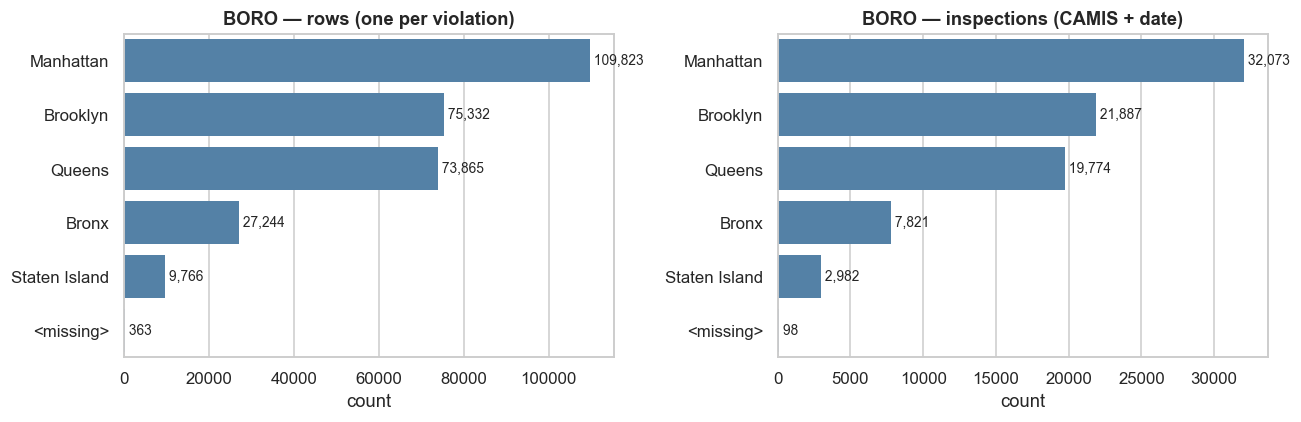

In [3]:
# BORO composition at two grains side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

row_counts = raw['BORO'].replace('0', '<missing>').value_counts()
insp_counts = inspections['BORO'].replace('0', '<missing>').value_counts()

for ax, series, label in [
    (axes[0], row_counts,  'rows (one per violation)'),
    (axes[1], insp_counts, 'inspections (CAMIS + date)'),
]:
    sns.barplot(x=series.values, y=series.index, ax=ax,
                color='steelblue', edgecolor='none')
    ax.set_title(f'BORO — {label}')
    ax.set_xlabel('count')
    ax.set_ylabel('')
    # Annotate each bar with the count.
    for i, v in enumerate(series.values):
        ax.text(v, i, f' {v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / '01_boro_two_grains.png', bbox_inches='tight')
plt.show()

## 2. When — inspection volume over time

The profile report says the date range runs 2007-08-10 → 2026-05-27 — but that's just min/max. A monthly count shows whether old years are sparsely represented (truncation) and where any obvious gaps live (e.g. the COVID-19 inspection halt in 2020).

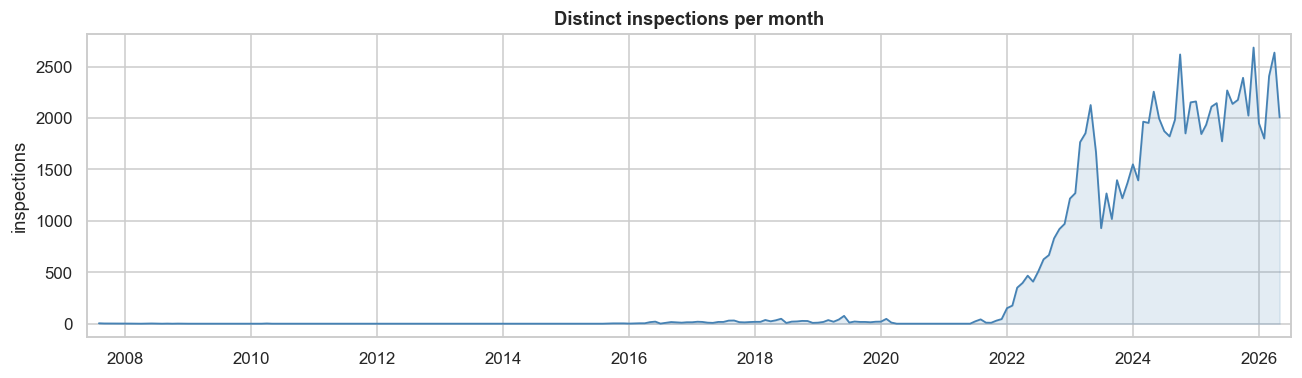

First non-empty month: 2007-08-01
Last  non-empty month: 2026-05-01
Median month: 2 inspections
Lowest 3 months by volume (likely shutdowns / sparse data):
inspection_dt
2007-11-01    1
2008-02-01    1
2008-01-01    1
Name: inspections, dtype: int64


In [4]:
# Monthly count of distinct inspections.
monthly = (
    inspections.set_index('inspection_dt')
               .resample('MS')                # month-start buckets
               .size()
               .rename('inspections')
)

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(monthly.index, monthly.values, color='steelblue', linewidth=1.2)
ax.fill_between(monthly.index, monthly.values, color='steelblue', alpha=0.15)
ax.set_title('Distinct inspections per month')
ax.set_xlabel('')
ax.set_ylabel('inspections')
ax.margins(x=0.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_inspections_per_month.png', bbox_inches='tight')
plt.show()

# Print a small fact-table to read alongside the chart.
first_yr = monthly[monthly > 0].index.min().year
last_yr  = monthly[monthly > 0].index.max().year
print(f'First non-empty month: {monthly[monthly > 0].index.min().date()}')
print(f'Last  non-empty month: {monthly[monthly > 0].index.max().date()}')
print(f'Median month: {int(monthly.median()):,} inspections')
print('Lowest 3 months by volume (likely shutdowns / sparse data):')
print(monthly[monthly > 0].sort_values().head(3))

## 3. Missingness of key columns

Same numbers as the text report, but at a glance. The bar to watch is `GRADE` (~51% blank) — it tells us severity signals must lean on `SCORE` and `ACTION` more than on the letter grade.

C:\Users\tonmo\AppData\Local\Temp\claude\ipykernel_5668\953634947.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct_missing.values, y=pct_missing.index,


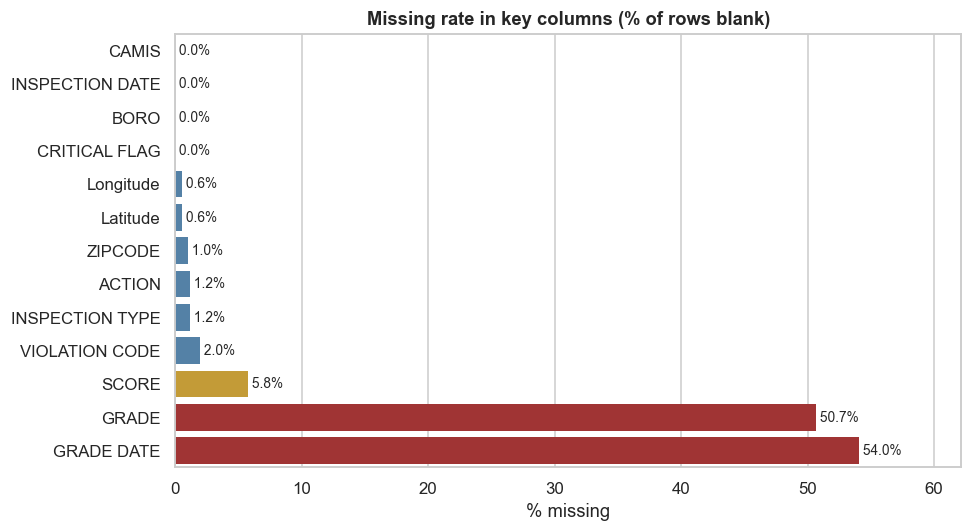

In [5]:
KEY = ['CAMIS', 'INSPECTION DATE', 'BORO', 'ZIPCODE', 'Latitude', 'Longitude',
       'ACTION', 'VIOLATION CODE', 'CRITICAL FLAG', 'SCORE', 'GRADE',
       'GRADE DATE', 'INSPECTION TYPE']

# % rows with empty string (we kept blanks as '' on load).
pct_missing = (raw[KEY].eq('').mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['firebrick' if p >= 25 else 'goldenrod' if p >= 5 else 'steelblue'
          for p in pct_missing.values]
sns.barplot(x=pct_missing.values, y=pct_missing.index,
            ax=ax, palette=colors, edgecolor='none')
ax.set_title('Missing rate in key columns (% of rows blank)')
ax.set_xlabel('% missing')
ax.set_ylabel('')
ax.set_xlim(0, max(pct_missing.max() * 1.15, 5))
for i, v in enumerate(pct_missing.values):
    ax.text(v, i, f' {v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_missingness.png', bbox_inches='tight')
plt.show()

## 4. What kind of inspections — `INSPECTION TYPE`

There are 38 distinct values, but most are tiny. Top categories tell us the data is dominated by **Cycle Inspections** (the routine annual visits) and their **Re-inspections** — that's the backbone of any re-inspection-speed angle.

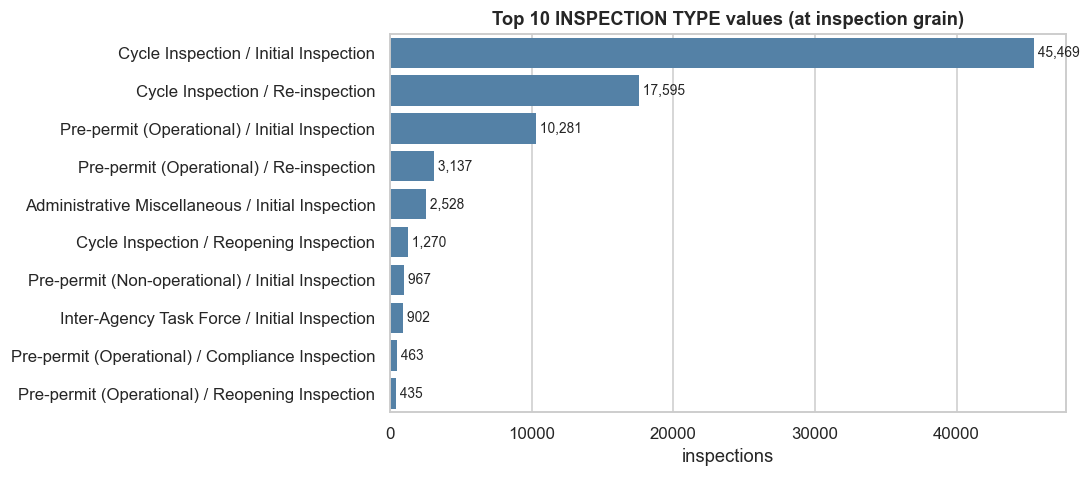

In [6]:
top = inspections['INSPECTION_TYPE'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(x=top.values, y=top.index, ax=ax,
            color='steelblue', edgecolor='none')
ax.set_title('Top 10 INSPECTION TYPE values (at inspection grain)')
ax.set_xlabel('inspections')
ax.set_ylabel('')
for i, v in enumerate(top.values):
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_inspection_types.png', bbox_inches='tight')
plt.show()

## 5. Severity signals — `SCORE`, `CRITICAL FLAG`, `GRADE`, `ACTION`

Four side-by-side views of how 'how bad was this inspection' is recorded. Recall: **higher `SCORE` = worse**; A/B/C grade thresholds map onto score bands DOHMH defines. Letter-graded inspections are typically Cycle inspections; many other inspections (re-inspections, pre-permit) have blank grades.

C:\Users\tonmo\AppData\Local\Temp\claude\ipykernel_5668\883001486.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=g.index, y=g.values, ax=ax, palette=colors, edgecolor='none')


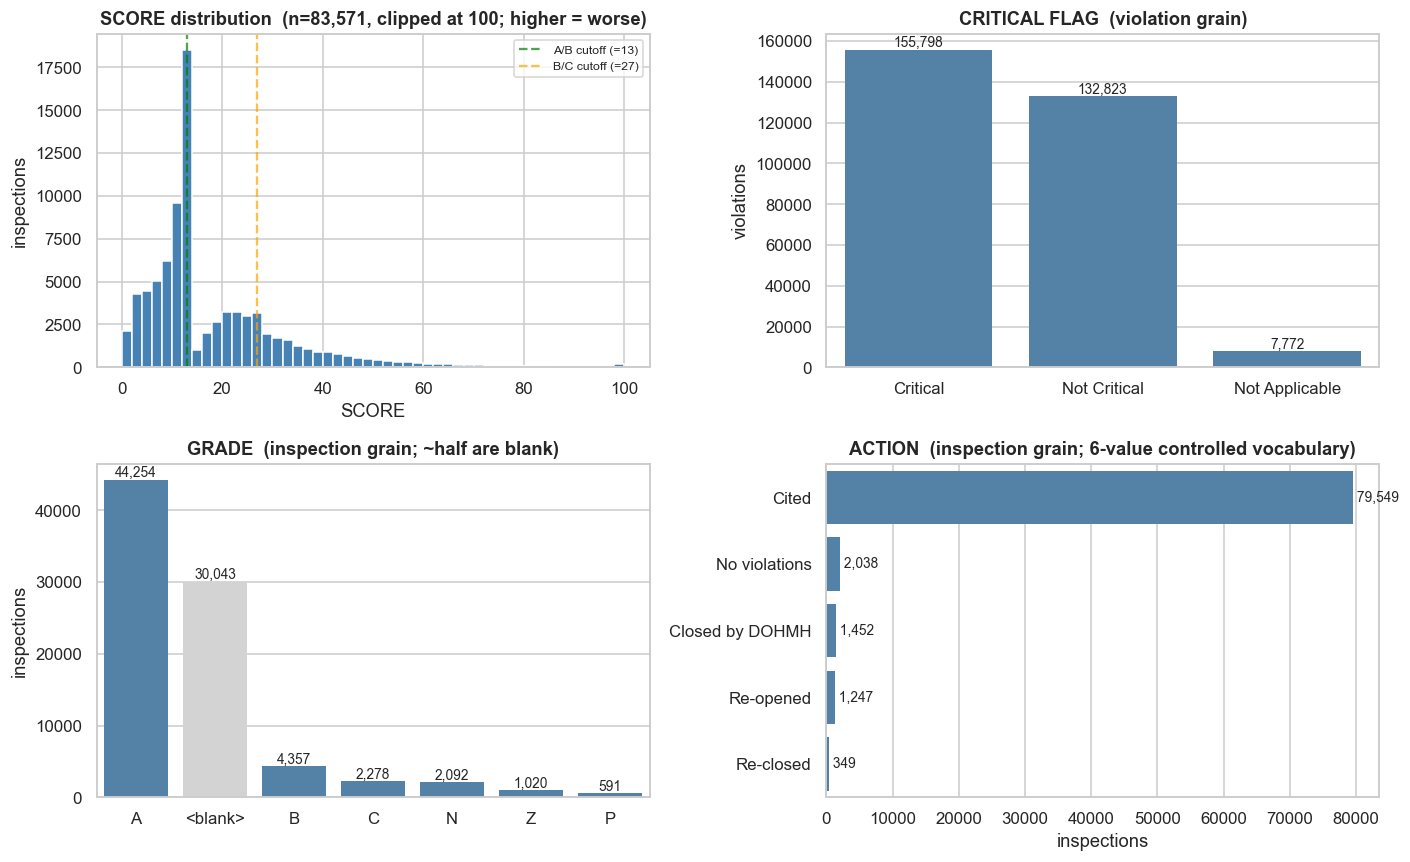

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (a) SCORE histogram, clipped at 100 for readability (heavy long tail).
ax = axes[0, 0]
s = inspections['SCORE'].dropna()
s_clip = s.clip(upper=100)
ax.hist(s_clip, bins=50, color='steelblue', edgecolor='white')
ax.axvline(13, color='green', linestyle='--', alpha=0.7, label='A/B cutoff (=13)')
ax.axvline(27, color='orange', linestyle='--', alpha=0.7, label='B/C cutoff (=27)')
ax.set_title(f'SCORE distribution  (n={len(s):,}, clipped at 100; higher = worse)')
ax.set_xlabel('SCORE')
ax.set_ylabel('inspections')
ax.legend(loc='upper right', fontsize=8)

# (b) CRITICAL FLAG — at *violation* grain (each row is a violation).
ax = axes[0, 1]
cf = raw['CRITICAL FLAG'].value_counts()
sns.barplot(x=cf.index, y=cf.values, ax=ax, color='steelblue', edgecolor='none')
ax.set_title('CRITICAL FLAG  (violation grain)')
ax.set_ylabel('violations')
ax.set_xlabel('')
for i, v in enumerate(cf.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# (c) GRADE — inspection grain, blanks made visible.
ax = axes[1, 0]
g = inspections['GRADE'].replace('', '<blank>').value_counts()
colors = ['lightgrey' if k == '<blank>' else 'steelblue' for k in g.index]
sns.barplot(x=g.index, y=g.values, ax=ax, palette=colors, edgecolor='none')
ax.set_title('GRADE  (inspection grain; ~half are blank)')
ax.set_ylabel('inspections')
ax.set_xlabel('')
for i, v in enumerate(g.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# (d) ACTION — inspection grain. Long labels -> abbreviate.
ax = axes[1, 1]
abbrev = {
    'Violations were cited in the following area(s).':  'Cited',
    'No violations were recorded at the time of this inspection.': 'No violations',
    'Establishment Closed by DOHMH. Violations were cited in the following area(s) and those requiring immediate action were addressed.': 'Closed by DOHMH',
    'Establishment re-opened by DOHMH.':  'Re-opened',
    'Establishment re-closed by DOHMH.':  'Re-closed',
    '': '<blank>',
}
a = (inspections['ACTION'].map(lambda x: abbrev.get(x, x))
                          .value_counts())
sns.barplot(x=a.values, y=a.index, ax=ax, color='steelblue', edgecolor='none')
ax.set_title('ACTION  (inspection grain; 6-value controlled vocabulary)')
ax.set_xlabel('inspections')
ax.set_ylabel('')
for i, v in enumerate(a.values):
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_severity_signals.png', bbox_inches='tight')
plt.show()

## 6. Re-inspection cadence — inspections per restaurant

Re-inspection-speed analysis needs restaurants with *at least two* inspections. Distribution below shows how many. Same numbers as the text report, but the shape (sharp peak at 2–4) is the takeaway.

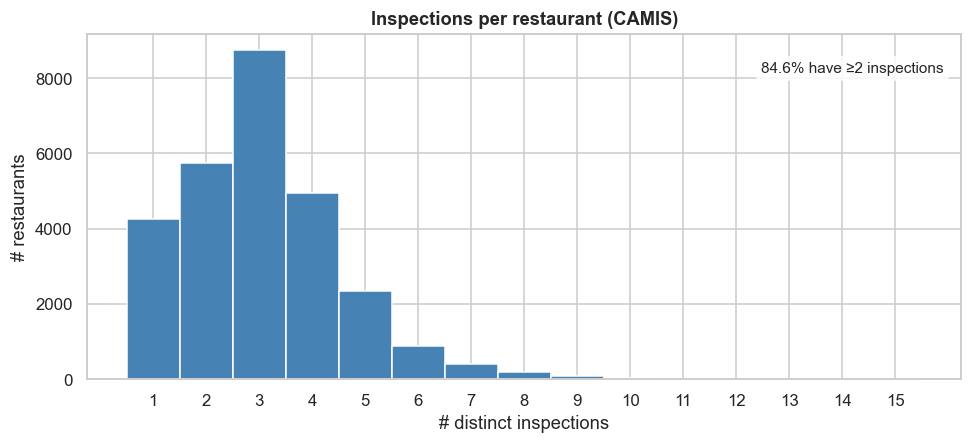

In [8]:
per_camis = inspections.groupby('CAMIS').size()
max_n = int(per_camis.max())

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(per_camis, bins=range(1, max_n + 2),
        color='steelblue', edgecolor='white', align='left')
ax.set_title('Inspections per restaurant (CAMIS)')
ax.set_xlabel('# distinct inspections')
ax.set_ylabel('# restaurants')
ax.set_xticks(range(1, max_n + 1))

# Annotate the share that have >= 2 (the analyzable subset for any gap study).
share_multi = (per_camis >= 2).mean() * 100
ax.text(0.98, 0.92, f'{share_multi:.1f}% have ≥2 inspections',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
plt.tight_layout()
plt.savefig(FIG_DIR / '06_inspections_per_camis.png', bbox_inches='tight')
plt.show()

---

All figures are also saved under `reports/figures/` so they can be looked at without re-running the notebook.

Next decision (over to the project owner): pick the analytical angle. The data shape supports several; this notebook hasn't chosen one.